Dieser Code trainiert und evaluiert zwei LSTM Modelle mit der Vektorisierung Bag of Words anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}


**Import**

In [1]:
 import pandas as pd
 import matplotlib.pyplot  as plt
 import seaborn as sns
 import numpy as np
 import sklearn
 import sklearn.metrics as metrics
 from sklearn.model_selection import train_test_split
 from tensorflow.keras.preprocessing.text import Tokenizer
 from tensorflow.keras.preprocessing.sequence import pad_sequences
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Daten einlesen**

In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [4]:
df["labels"].isna().sum()
df[df["labels"].isna()]


,text,labels,source,dataset,nb_annotators
2519,Das macht Angst....,NaN,None,None,NaN


In [5]:
df=df.dropna(subset=["labels"])

In [6]:
df["labels"].isna().sum()

np.int64(0)

In [7]:
X=df["text"]
y=df["labels"].astype(int)

**Datensatz einteilen**

In [8]:
from sklearn.model_selection import train_test_split
X=df["text"]
y=df["labels"].astype(int)

In [9]:
#TRAIN /TEST
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#TRAIN / VALIDATION
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.1, random_state=42)

In [11]:
tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [12]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

maxlen=175
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=maxlen, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post')

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


**Modell trainieren**

In [14]:
modellBidirectional=Sequential()
modellBidirectional.add(Embedding(input_dim=50000, output_dim=64, input_length=maxlen))
modellBidirectional.add(LSTM(128,return_sequences=True, dropout=0.3, recurrent_dropout=0.3))
modellBidirectional.add(Bidirectional(LSTM(128)))
modellBidirectional.add(Dropout(0.3))
modellBidirectional.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
modellBidirectional.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
historyBidirectional=modellBidirectional.fit(
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 374s 641ms/step - accuracy: 0.8818 - loss: 0.3167 - val_accuracy: 0.8900 - val_loss: 0.2970
Epoch 2/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 371s 630ms/step - accuracy: 0.9135 - loss: 0.2236 - val_accuracy: 0.8956 - val_loss: 0.2754
Epoch 3/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 363s 638ms/step - accuracy: 0.9387 - loss: 0.1630 - val_accuracy: 0.8964 - val_loss: 0.2865
Epoch 4/10
569/569 ━━━━━━━━━━━━━━━━━━━━ 384s 641ms/step - accuracy: 0.9550 - loss: 0.1200 - val_accuracy: 0.8922 - val_loss: 0.3109


In [16]:
#Modell speichern
import joblib
joblib.dump(modellBidirectional,"/content/drive/MyDrive/Colab Notebooks/LSTM_Bidirectional_model_normal.plk")

['/content/drive/MyDrive/Colab Notebooks/LSTM_Bidirectional_model_normal.plk']

**Modell validieren**

In [17]:
y_val_proba=modellBidirectional.predict(X_val_padded).flatten()
y_valpred=(y_val_proba>0.5).astype(int)

#wahrscheinlichkeit speichern
with open("lstm_validierung_bidirectional_normal.txt","w") as fd:
  for text, label, proba in zip(X_val, y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {label}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)


#Klassifikationsschwellen
schwellen=np.arange(0.0,1.01,0.01)
beste_schwelle=0
bester_f1=0
for t in schwellen:
  y_val_pred_schwelle=(y_val_proba>t).astype(int)
  f1=metrics.f1_score(y_val,y_val_pred_schwelle)
  if f1>bester_f1:
    bester_f1=f1
    beste_schwelle=t
    print(f"Beste Schwelle: {beste_schwelle}\n")
    print(f"Beste F1-Score: {bester_f1}\n")

print(f"Beste Schwellenwert: {beste_schwelle}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step
Beste Schwelle: 0.0

Beste F1-Score: 0.2185022026431718

Beste Schwelle: 0.01

Beste F1-Score: 0.26481994459833796

Beste Schwelle: 0.02

Beste F1-Score: 0.3284132841328413

Beste Schwelle: 0.03

Beste F1-Score: 0.37664618086040386

Beste Schwelle: 0.04

Beste F1-Score: 0.41437007874015747

Beste Schwelle: 0.05

Beste F1-Score: 0.43283582089552236

Beste Schwelle: 0.06

Beste F1-Score: 0.45157593123209167

Beste Schwelle: 0.07

Beste F1-Score: 0.463855421686747

Beste Schwelle: 0.08

Beste F1-Score: 0.47914032869785084

Beste Schwelle: 0.09

Beste F1-Score: 0.4947089947089947

Beste Schwelle: 0.1

Beste F1-Score: 0.5093425605536333

Beste Schwelle: 0.11

Beste F1-Score: 0.5175125089349535

Beste Schwelle: 0.12

Beste F1-Score: 0.5226939970717424

Beste Schwelle: 0.13

Beste F1-Score: 0.531930879038317

Beste Schwelle: 0.14

Beste F1-Score: 0.5385802469135802

Beste Schwelle: 0.15

Beste F1-Score: 0.5464654487688642

Beste Schwelle: 0.16

Best

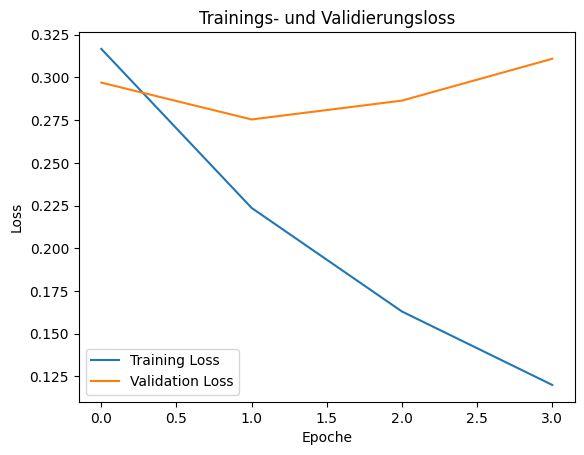

In [18]:
plt.plot(historyBidirectional.history['loss'], label='Training Loss')
plt.plot(historyBidirectional.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.title("Trainings- und Validierungsloss")
plt.show()

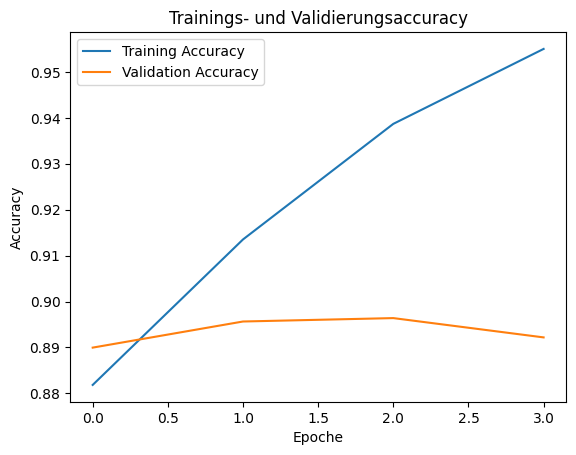

In [19]:
plt.plot(historyBidirectional.history['accuracy'], label='Training Accuracy')
plt.plot(historyBidirectional.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Trainings- und Validierungsaccuracy")
plt.show()

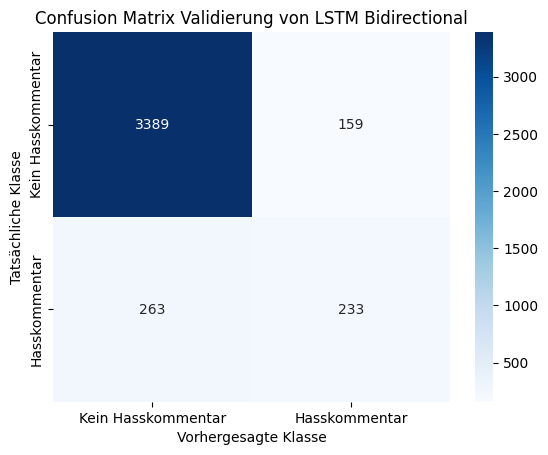

In [20]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_valpred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Validierung von LSTM Bidirectional")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [21]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_valpred)
# precision
vprecision = metrics.precision_score(y_val, y_valpred)
# recall
vrecall = metrics.recall_score(y_val, y_valpred)
# f1-score
vf1=metrics.f1_score(y_val, y_valpred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_valpred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_valpred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_valpred, average='macro')

In [22]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8956478733926805
Precision:  0.5943877551020408
Recall:  0.46975806451612906
Specificity:  0.9551860202931229
F1-Score:  0.5247747747747747
Macro Recall:  0.712472042404626
Macro F1-Score:  0.7330818318318318


#Modell evaluieren
**Standard Wert**

In [23]:
y_pred=(modellBidirectional.predict(X_test_padded)>0.5).astype(int)
#print(classification_report(y_test,y_pred)

316/316 ━━━━━━━━━━━━━━━━━━━━ 46s 144ms/step


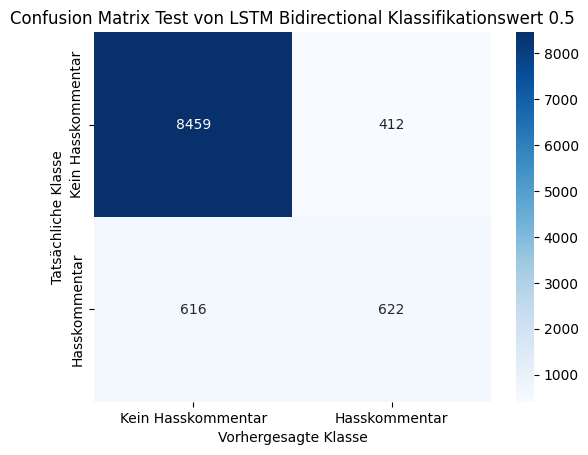

In [24]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Test von LSTM Bidirectional Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [25]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [26]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8983084380255218
Precision:  0.6015473887814313
Recall:  0.5024232633279483
Specificity:  0.9535565325216999
F1-Score:  0.5475352112676056
Macro Recall:  0.727989897924824
Macro F1-Score:  0.7451261256382606


**evaluieren beste Schwelle**

In [27]:
y_pred=(modellBidirectional.predict(X_test_padded)>beste_schwelle).astype(int)
#print(classification_report(y_test,y_pred)

316/316 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step


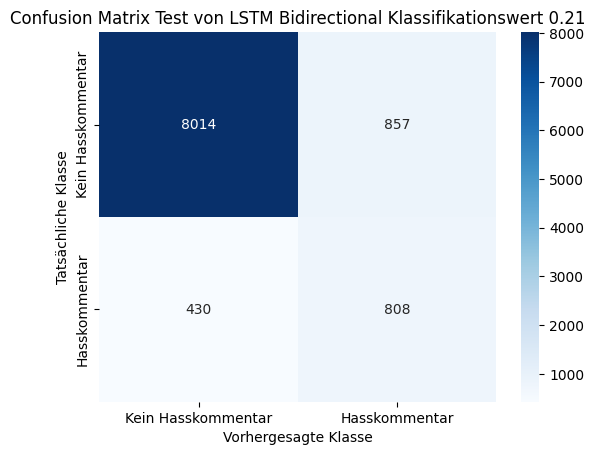

In [28]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title(f"Confusion Matrix Test von LSTM Bidirectional Klassifikationswert {beste_schwelle}")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [29]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [30]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8726877040261154
Precision:  0.4852852852852853
Recall:  0.6526655896607432
Specificity:  0.9033930785706233
F1-Score:  0.5566655184292112
Macro Recall:  0.7780293341156832
Macro F1-Score:  0.7411684508114869
